In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split,cross_val_predict,cross_val_score,cross_validate
from sklearn.preprocessing import OneHotEncoder, StandardScaler, PolynomialFeatures, RobustScaler
from sklearn.compose import ColumnTransformer
from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score,f1_score


In [ ]:
df = pd.read_csv(f"datasets/insurance.csv")

In [ ]:
df.head()

In [ ]:
df.info()

In [ ]:
df.columns

In [ ]:
df.shape

In [ ]:
df.value_counts()

In [ ]:
df.nunique()

In [ ]:
df["sex"] =df["sex"].map({"female":1,"male":0})
df["smoker"] = df["smoker"].map({"yes":1,"no":0})
df.head()

In [ ]:
df["sex"].value_counts()

In [ ]:
df["smoker"].value_counts()

In [ ]:
X = df.drop("charges",axis=1)
y = df["charges"]

print(f"X shape{X.shape}")
print(f"y shape{y.shape}")

In [ ]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,train_size=0.8,random_state=42)
print(f"Train: {len(X_train)}")
print(f"Test: {len(X_test)}")

In [ ]:
ohe = OneHotEncoder(drop="first",sparse_output=False)
scaler = RobustScaler()

preprocessor= ColumnTransformer(
    transformers=[
        ("num_scaling", scaler, ["age","bmi","children"]),
        ("region_encoding",ohe,["region"])
    ],
    remainder="passthrough"
)
X_train_encoded = preprocessor.fit_transform(X_train)
X_test_encoded = preprocessor.transform(X_test)

In [ ]:
X_train_encoded.shape

In [ ]:
X_test_encoded.shape

In [ ]:
type(X_train_encoded)

In [ ]:
feature_names = preprocessor.get_feature_names_out()
X_train_df = pd.DataFrame(X_train_encoded,columns=feature_names)
X_train_df.head()

In [ ]:
print(f"\nFinal feature count: {X_train_df.shape[1]}")

In [ ]:
AGE_IDX = 0
X_train_simple = X_train_encoded[:, [AGE_IDX]]
X_test_simple = X_test_encoded[:, [AGE_IDX]]

slr = LinearRegression()
slr.fit(X_train_simple,y_train)
y_pred_simple = slr.predict(X_test_simple)

print(f"Intercept: {slr.intercept_:.2f}")
print(f"Slope: {slr.coef_[0]:.2f}")

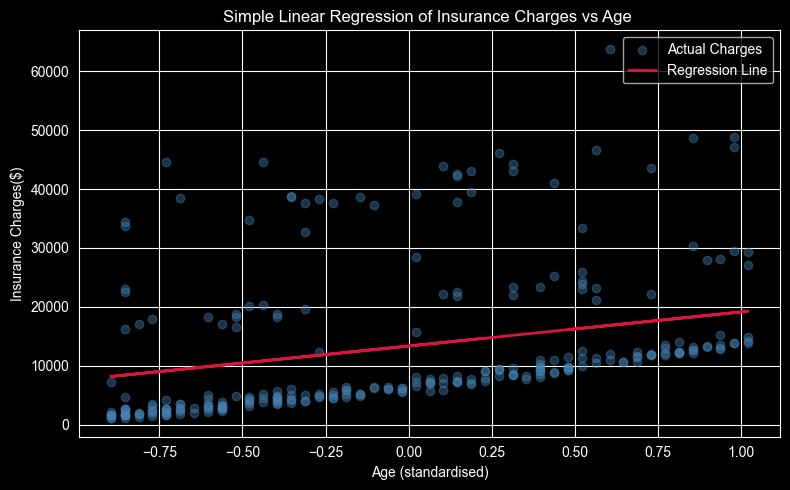

In [22]:
plt.figure(figsize=(8,5))
plt.scatter(X_test_simple,y_test,alpha=0.4,label="Actual Charges",color="steelblue")
plt.plot(X_test_simple,y_pred_simple,color="crimson",linewidth=2,label="Regression Line")
plt.title("Simple Linear Regression of Insurance Charges vs Age ")
plt.xlabel("Age (standardised)")
plt.ylabel("Insurance Charges($)")
plt.legend()
plt.tight_layout()
plt.show()

In [23]:
mae = mean_absolute_error(y_test,y_pred_simple)
mse = mean_squared_error(y_test,y_pred_simple)
rmse = np.sqrt(mse)
r2 = r2_score(y_test,y_pred_simple)

print("Simple Linear Regression Results")
print(f"Mean Absolute Error:{mae:.2f}")
print(f"Mean Squared Error:{mse:.2f}")
print(f"Root Mean Squared Error:{rmse:.2f}")
print(f"R squared :{r2:.2f} ")

Simple Linear Regression Results
Mean Absolute Error:9173.26
Mean Squared Error:135983957.48
Root Mean Squared Error:11661.22
R squared :0.12 


Polynomial Regression (Still one feature, age)

In [24]:
spr= PolynomialFeatures(degree=2,include_bias=False)

X_train_simple_poly = spr.fit_transform(X_train_simple)
X_test_simple_poly = spr.transform(X_test_simple)

spr_age_model = LinearRegression()
spr_age_model.fit(X_train_simple_poly,y_train)
y_pred_simple_poly = spr_age_model.predict(X_test_simple_poly)

mae_sp = mean_absolute_error(y_test,y_pred_simple_poly)
mse_sp = mean_squared_error(y_test,y_pred_simple_poly)
rmse_sp = np.sqrt(mse_sp)
r2_sp = r2_score(y_test,y_pred_simple_poly)

print("Simple 2nd Degree Polynomial Regression on Age vs Insurance Charges Results")
print(f"Mean Absolute Error:{mae_sp:.2f}")
print(f"Mean Squared Error:{mse_sp:.2f}")
print(f"Root Mean Squared Error:{rmse_sp:.2f}")
print(f"R squared :{r2_sp:.2f} ")

Simple 2nd Degree Polynomial Regression on Age vs Insurance Charges Results
Mean Absolute Error:9189.48
Mean Squared Error:136815004.01
Root Mean Squared Error:11696.79
R squared :0.12 


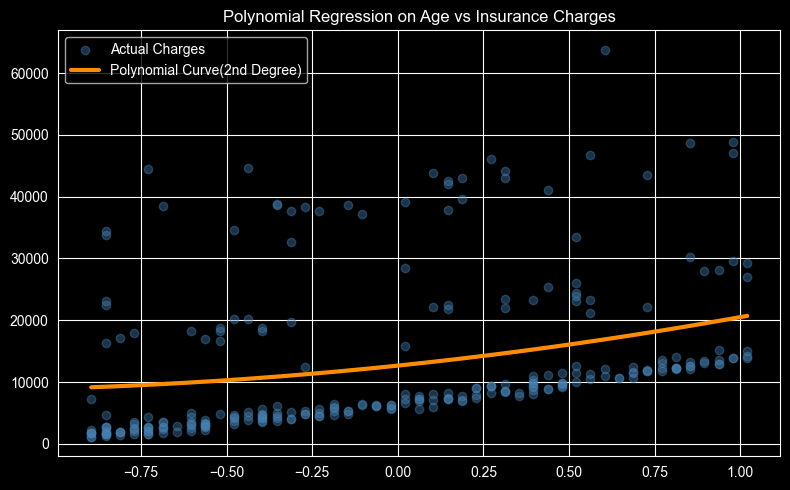

In [26]:
age_seq = np.linspace(X_test_simple.min(),X_test_simple.max() ,100).reshape(-1,1)

age_seq_poly = spr.transform(age_seq)

smooth_curve_pred = spr_age_model.predict(age_seq_poly)

plt.figure(figsize=(8,5))
plt.scatter(X_test_simple,y_test,alpha=0.4,label="Actual Charges",color="steelblue")
plt.plot(age_seq,smooth_curve_pred,color="darkorange",linewidth=3,label="Polynomial Curve(2nd Degree)")
plt.title("Polynomial Regression on Age vs Insurance Charges")
plt.legend()
plt.tight_layout()
plt.show()

In [29]:
poly_overfit = PolynomialFeatures(degree=15,include_bias=False)

X_train_overfit= poly_overfit.fit_transform(X_train_simple)
X_test_overfit = poly_overfit.transform(X_test_simple)

model_overfit = LinearRegression()
model_overfit.fit(X_train_overfit,y_train)
y_pred_overfit = model_overfit.predict(X_test_overfit)

mae_overfit  = mean_absolute_error(y_test, y_pred_overfit)
mse_overfit  = mean_squared_error(y_test, y_pred_overfit)
rmse_overfit = np.sqrt(mse_overfit)
r2_overfit   = r2_score(y_test, y_pred_overfit)

print("--- Polynomial Regression (Age Only, Degree 15) ---")
print(f"MAE  : {mae_overfit:.2f}")
print(f"RMSE : {rmse_overfit:.2f}")
print(f"R²   : {r2_overfit:.4f}")

--- Polynomial Regression (Age Only, Degree 15) ---
MAE  : 9231.94
RMSE : 11818.27
R²   : 0.1003


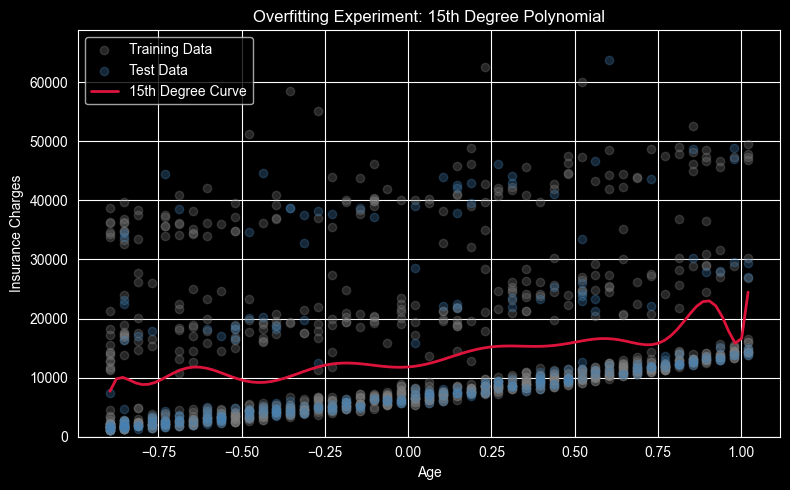

In [32]:
age_seq_overfit= poly_overfit.transform(age_seq)
smooth_curve_pred_overfit = model_overfit.predict(age_seq_overfit)

plt.figure(figsize=(8,5))
plt.scatter(X_train_simple,y_train,alpha=0.3,label="Training Data",color="gray")
plt.scatter(X_test_simple,y_test,alpha=0.3,label="Test Data",color="steelblue")

plt.plot(age_seq,smooth_curve_pred_overfit,color="crimson",linewidth=2,label="15th Degree Curve")
plt.ylim(0,y.max()+5000)
plt.title("Overfitting Experiment: 15th Degree Polynomial")
plt.xlabel("Age")
plt.ylabel("Insurance Charges")
plt.legend()
plt.tight_layout()
plt.show()

In [33]:
mlr_model = LinearRegression()
mlr_model.fit(X_train_encoded,y_train)
y_pred_multi = mlr_model.predict(X_test_encoded)

mae_multi  = mean_absolute_error(y_test, y_pred_multi)
mse_multi  = mean_squared_error(y_test, y_pred_multi)
rmse_multi = np.sqrt(mse_multi)
r2_multi   = r2_score(y_test, y_pred_multi)

print("--- Multiple Linear Regression Results ---")
print(f"MAE  : {mae_multi:.2f}")
print(f"MSE  : {mse_multi:.2f}")
print(f"RMSE : {rmse_multi:.2f}")
print(f"R²   : {r2_multi:.4f}")

--- Multiple Linear Regression Results ---
MAE  : 4181.19
MSE  : 33596915.85
RMSE : 5796.28
R²   : 0.7836


In [34]:
poly = PolynomialFeatures(degree=2,include_bias=False)

X_train_poly = poly.fit_transform(X_train_encoded)
X_test_poly = poly.transform(X_test_encoded)

print(f"Original features   : {X_train_encoded.shape[1]}")
print(f"Polynomial features : {X_train_poly.shape[1]}")
print("(Features explode fast. This is why overfitting risk increases with degree!)")

Original features   : 8
Polynomial features : 44
(Features explode fast. This is why overfitting risk increases with degree!)


In [35]:
poly_model = LinearRegression()
poly_model.fit(X_train_poly,y_train)
y_pred_poly= poly_model.predict(X_test_poly)

mae_poly  = mean_absolute_error(y_test, y_pred_poly)
mse_poly  = mean_squared_error(y_test, y_pred_poly)
rmse_poly = np.sqrt(mse_poly)
r2_poly   = r2_score(y_test, y_pred_poly)

print("--- Polynomial Regression (Degree 2) Results ---")
print(f"MAE  : {mae_poly:.2f}")
print(f"MSE  : {mse_poly:.2f}")
print(f"RMSE : {rmse_poly:.2f}")
print(f"R²   : {r2_poly:.4f}")

--- Polynomial Regression (Degree 2) Results ---
MAE  : 2729.50
MSE  : 20712805.99
RMSE : 4551.13
R²   : 0.8666


                                        MAE      RMSE      R²
Model                                                        
1. Simple LR (Age)                  9173.26  11661.22  0.1241
2. Poly LR (Age, deg=2)             9189.48  11696.79  0.1187
3. Poly LR (Age, deg=15) [Overfit]  9231.94  11818.27  0.1003
4. Multiple LR (All)                4181.19   5796.28  0.7836
5. Poly LR (All, deg=2)             2729.50   4551.13  0.8666


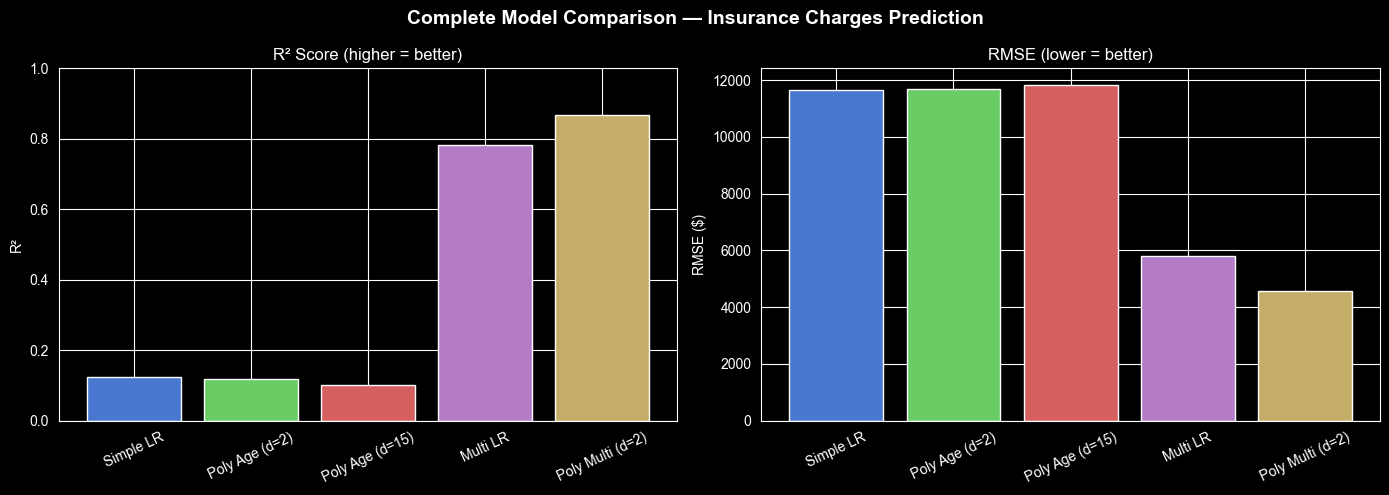

In [36]:


results = pd.DataFrame({
    'Model': [
        '1. Simple LR (Age)',
        '2. Poly LR (Age, deg=2)',
        '3. Poly LR (Age, deg=15) [Overfit]',
        '4. Multiple LR (All)',
        '5. Poly LR (All, deg=2)'
    ],
    'MAE':  [mae,mae_sp, mae_overfit, mae_multi, mae_poly],
    'RMSE': [rmse, np.sqrt(mean_squared_error(y_test, y_pred_simple_poly)), rmse_overfit, rmse_multi, rmse_poly],
    'R²':   [r2, r2_sp, r2_overfit, r2_multi, r2_poly],
})

results = results.set_index('Model')
results = results.round({'MAE': 2, 'RMSE': 2, 'R²': 4})
print(results.to_string())

# Plotting the metrics for visual comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# We use shorthand labels for the x-axis to keep it readable
models_labels = ['Simple LR', 'Poly Age (d=2)', 'Poly Age (d=15)', 'Multi LR', 'Poly Multi (d=2)']
r2_vals   = results['R²'].values
rmse_vals = results['RMSE'].values
colors    = ['#4878CF', '#6ACC65', '#D65F5F', '#B47CC7', '#C4AD66']

# R-squared Plot
axes[0].bar(models_labels, r2_vals, color=colors)
axes[0].set_title('R² Score (higher = better)')
axes[0].set_ylim(0, 1)
axes[0].set_ylabel('R²')
axes[0].tick_params(axis='x', rotation=25)

# RMSE Plot
axes[1].bar(models_labels, rmse_vals, color=colors)
axes[1].set_title('RMSE (lower = better)')
axes[1].set_ylabel('RMSE ($)')
axes[1].tick_params(axis='x', rotation=25)

plt.suptitle('Complete Model Comparison — Insurance Charges Prediction', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()



In [37]:
cv_model = LinearRegression()

cv_scores = cross_val_score(cv_model,X_train_poly,y_train,cv=5,scoring="r2")

print("--- 5-Fold Cross-Validation (Poly LR, Degree 2) ---")
print(f"Individual Fold R² Scores : {cv_scores}")
print(f"Mean CV R² Score          : {cv_scores.mean():.4f}")
print(f"Score Standard Deviation  : {cv_scores.std():.4f}")

# Compare it to our previous single test-set R2
print(f"\nOriginal Single Test R²   : {r2_poly:.4f}")

--- 5-Fold Cross-Validation (Poly LR, Degree 2) ---
Individual Fold R² Scores : [0.82480662 0.89475206 0.79985192 0.76020001 0.85461197]
Mean CV R² Score          : 0.8268
Score Standard Deviation  : 0.0459

Original Single Test R²   : 0.8666
